**Assignment 2- CNN**

Marston Ward

In [1]:
# Import libraries - compatible with Keras 3.x
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
# Set TensorFlow random seed
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

# Use keras (standalone) for Keras 3.x compatibility
import keras
from keras.datasets import mnist, cifar10 # type: ignore
from keras.models import Sequential # type: ignore
from keras.layers import Dense, Dropout, Flatten, Activation, Conv2D, MaxPooling2D, BatchNormalization # type: ignore
from keras.utils import to_categorical, image_dataset_from_directory # type: ignore
from keras.optimizers import SGD, Adam # type: ignore
import keras.backend as K # type: ignore

print(f"Keras version: {keras.__version__}")
print(f"NumPy version: {np.__version__}")
print("Using Keras 3.x - ImageDataGenerator replaced with tf.data and image utilities")

TensorFlow version: 2.19.0
Keras version: 3.10.0
NumPy version: 2.0.2
Using Keras 3.x - ImageDataGenerator replaced with tf.data and image utilities


In [2]:
# Create train and test dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f'Training data shape: {X_train.shape}')
print(f'Training labels shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

# Let's look at the raw data values
print(np.unique(X_train[0]))  # Print the pixel values of the first training image

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)
Pixel value range: 0 to 255
[  0   1   2   3   9  11  14  16  18  23  24  25  26  27  30  35  36  39
  43  45  46  49  55  56  64  66  70  78  80  81  82  90  93  94 107 108
 114 119 126 127 130 132 133 135 136 139 148 150 154 156 160 166 170 171
 172 175 182 183 186 187 190 195 198 201 205 207 212 213 219 221 225 226
 229 238 240 241 242 244 247 249 250 251 252 253 255]


1.a. start with creating a visualization of your input data

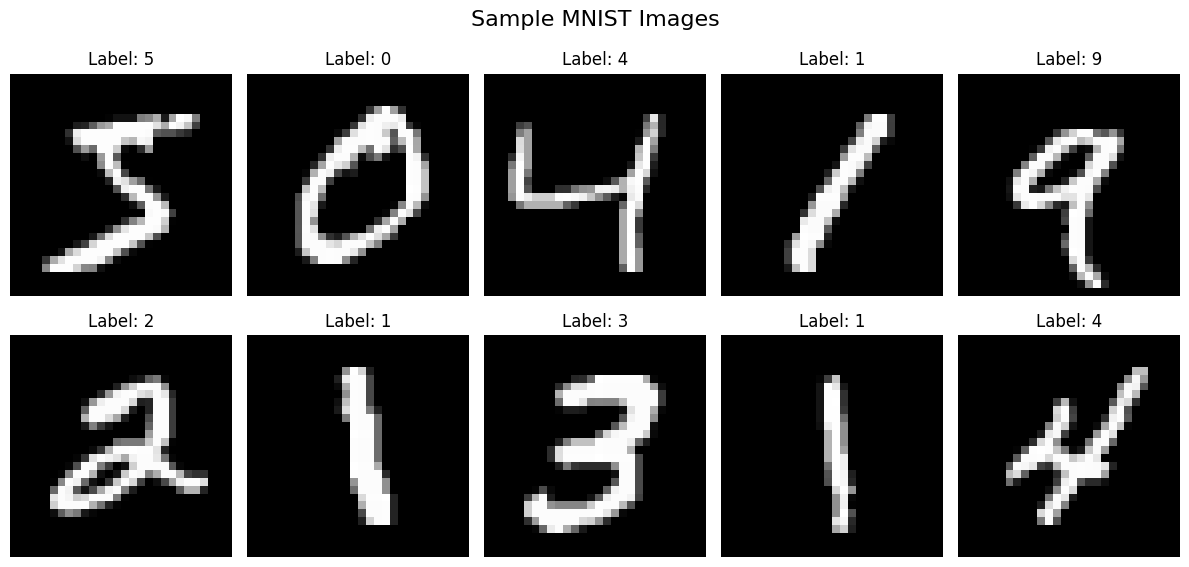

Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


In [3]:
#1.a. Create the visualization here
# Let's look into the dataset by visualizing some data points

# Plot some sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Images', fontsize=16)

for i in range(10):
    row = i // 5
    col = i % 5
    axes[row, col].imshow(X_train[i], cmap='gray')
    axes[row, col].set_title(f'Label: {y_train[i]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print some statistics
print(f'Number of classes: {len(np.unique(y_train))}')
print(f'Classes: {np.unique(y_train)}')

In [4]:
# Preprocessing
# Keras allows us to add the number of channels either to the beginning of shape or the end of it

# Extract image dimensions from the data itself. This is a more dynamic approach that hardcoding information that
# is already known.
img_rows, img_cols = X_train.shape[1], X_train.shape[2]

# Changed to use np.newaxis for clarity
if K.image_data_format() == 'channels_first':
    print("Using channels_first format")
    # Add channel dimension at position 1: (batch, 1, height, width)
    X_train = X_train[:, np.newaxis, :, :]
    X_test = X_test[:, np.newaxis, :, :]
    input_shape = (1, img_rows, img_cols)
else:
    print(f'Keras backend is: {K.image_data_format()}')
    print("Using channels_last format")
    # Add channel dimension at the end: (batch, height, width, 1)
    X_train = X_train[..., np.newaxis]
    X_test = X_test[..., np.newaxis]
    input_shape = (img_rows, img_cols, 1)

print(f'Training data shape: {X_train.shape}')
print(f'Training labels shape: {y_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Test labels shape: {y_test.shape}')
print(f'Input shape for CNN: {input_shape}')
print(f'Pixel value range: {X_train.min()} to {X_train.max()}')

# Let's look at the raw data values
print(f'Sample pixel values from first image: {np.unique(X_train[0])[:10]}...')  # Show first 10 unique values

Keras backend is: channels_last
Using channels_last format
Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000,)
Input shape for CNN: (28, 28, 1)
Pixel value range: 0 to 255
Sample pixel values from first image: [ 0  1  2  3  9 11 14 16 18 23]...


In [5]:
# Apply preprocessing to X and y

# normalize inputs from 0-255 to 0-1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f'Normalized pixel value range: Train => {X_train.min():.3f} to {X_train.max():.3f}')
print(f'Normalized pixel value range: Test => {X_test.min():.3f} to {X_test.max():.3f}')

# Encode outputs (one-hot encoding)
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

print(f'Training labels shape after one-hot encoding: {y_train.shape}')
print(f'Test labels shape after one-hot encoding: {y_test.shape}')
print(f'Sample encoded label: {y_train[0]}')

Normalized pixel value range: Train => 0.000 to 1.000
Normalized pixel value range: Test => 0.000 to 1.000
Training labels shape after one-hot encoding: (60000, 10)
Test labels shape after one-hot encoding: (10000, 10)
Sample encoded label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


1.b. Create a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has one hidden layer (512 nodes). Draw the Learning curve. What is your understanding from learning curve? Batch size=128 and epochs=20

In [6]:
#1.b.
# Create CNN model with 4 convolution layers (2x32 filters, 2x64 filters)
# Fully connected layer with one hidden layer (512 nodes)

model = Sequential()
# Add Input layer explicitly
model.add(keras.Input(shape=input_shape))

# 1st convolution layer - 32 filters
model.add(Conv2D(32, (3, 3), activation='relu')) # input_shape is now defined by the Input layer
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd convolution layer - 32 filters
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd convolution layer - 64 filters. Choose padding solution to maintain spatial dimensions.
# Why padding='same' is best solution:
# - Maintains assignment requirements - still 4 convolution layers as specified
# - Standard practice - most modern CNNs use same padding
# - Preserves learning capacity - keeps spatial feature extraction
# - Minimal impact - small computational overhead
# - Prevents dimension collapse - allows the network to learn effectively
# The error occurs because after 3 MaxPooling layers (each halving dimensions),
# the 28×28 input becomes very small, and the 4th conv layer without padding tries
# to apply a 3×3 kernel to insufficient spatial dimensions.
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4th convolution layer - 64 filters (add padding='same' to prevent negative output size)
model.add(Conv2D(64, (3, 3), padding='same', activation='relu'))

# Flatten the output from convolutional layers
model.add(Flatten())

# Fully connected layer with 512 nodes
model.add(Dense(512, activation='relu'))

# Output layer for 10 classes
model.add(Dense(num_classes, activation='softmax'))

# Print model summary
print("MNIST CNN Model Summary:")
model.summary()

MNIST CNN Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,706 (787.91 KB)

 Trainable params: 201,706 (787.91 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Check Apple Silicon GPU availability (Metal backend)
print("Apple Silicon GPU Information:")
print(f"TensorFlow version: {tf.__version__}")
print(f"TensorFlow built with CUDA: {tf.test.is_built_with_cuda()}")

# Check for Apple Silicon GPU (Metal)
physical_devices = tf.config.list_physical_devices()
print(f"All physical devices: {physical_devices}")

gpu_devices = tf.config.list_physical_devices('GPU')
print(f"GPU devices: {gpu_devices}")

# Check for Apple Silicon specific devices
try:
    # For Apple Silicon, TensorFlow uses Metal backend
    logical_gpus = tf.config.experimental.list_logical_device_configuration(gpu_devices[0]) if gpu_devices else None
    print(f"Logical GPU config: {logical_gpus}")
except:
    print("No GPU configuration available")

if gpu_devices:
    print("✅ Apple Silicon GPU detected - training will use Metal acceleration")
    print(f"GPU device: {gpu_devices[0]}")

    # Enable memory growth for Apple Silicon GPU
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory growth enabled for GPU")
    except Exception as e:
        print(f"Note: {e}")
else:
    print("⚠️ No GPU detected - training will use CPU")

# Test GPU with a simple operation
try:
    with tf.device('/GPU:0'):
        a = tf.constant([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
        b = tf.constant([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
        c = tf.matmul(a, b)
        print("✅ GPU test operation successful")
        print(f"Test result shape: {c.shape}")
except Exception as e:
    print(f"GPU test failed: {e}")
    print("Will use CPU for training")

Apple Silicon GPU Information:
TensorFlow version: 2.19.0
TensorFlow built with CUDA: True
All physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
No GPU configuration available
✅ Apple Silicon GPU detected - training will use Metal acceleration
GPU device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
Note: Physical devices cannot be modified after being initialized
✅ GPU test operation successful
Test result shape: (2, 2)


In [8]:
# Debug: Check current data shapes
print("Current data shapes:")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")

Current data shapes:
X_train.shape: (60000, 28, 28, 1)
y_train.shape: (60000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)


In [9]:
# Fix: Reload and reprocess data correctly
print("Reloading and preprocessing MNIST data...")

# Reload fresh data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Add channel dimension (only once!)
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

# Normalize
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode (only once!)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("After correct preprocessing:")
print(f"X_train.shape: {X_train.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test.shape: {X_test.shape}")
print(f"y_test.shape: {y_test.shape}")
print("✅ Data shapes are now correct for training!")

Reloading and preprocessing MNIST data...
After correct preprocessing:
X_train.shape: (60000, 28, 28, 1)
y_train.shape: (60000, 10)
X_test.shape: (10000, 28, 28, 1)
y_test.shape: (10000, 10)
✅ Data shapes are now correct for training!


In [10]:
# Optimizer minimizes the loss function and update the weights. Using Adam
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model with batch_size=128 and epochs=20 as specified
batch_size = 128
epochs = 20

print(f"Training with batch_size={batch_size} and epochs={epochs}")
print(f"Using seed={SEED} for reproducible shuffling")

hist = model.fit(X_train, y_train,
                 batch_size=batch_size,
                 epochs=epochs,
                 verbose=1,
                 validation_data=(X_test, y_test),
                 shuffle=True)  # Shuffle is True by default, but explicit for clarity

Training with batch_size=128 and epochs=20
Using seed=42 for reproducible shuffling
Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8135 - loss: 0.6047 - val_accuracy: 0.9792 - val_loss: 0.0664
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9786 - loss: 0.0700 - val_accuracy: 0.9817 - val_loss: 0.0570
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9852 - loss: 0.0475 - val_accuracy: 0.9840 - val_loss: 0.0504
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9885 - loss: 0.0355 - val_accuracy: 0.9870 - val_loss: 0.0413
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9916 - loss: 0.0286 - val_accuracy: 0.9904 - val_loss: 0.0313
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9931 - loss: 0.0223 - val_accuracy: 0.9907 - val_loss: 0.0309
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9918 - val_loss: 0.0302
Epoch 8/20
469/469

In [11]:
# Measure test accuracy
scores = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {scores[0]:.4f}")
print(f"Test Accuracy: {scores[1]*100:.2f}%")

Test Loss: 0.0487
Test Accuracy: 98.94%


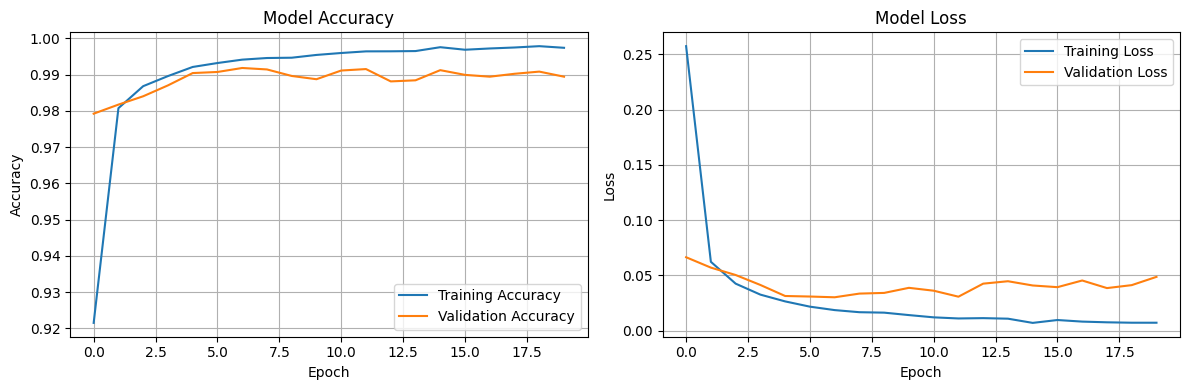

In [12]:
# Draw Learning curve
def learning_curve(hist):
    """Create a function to draw learning curves"""
    # Plot training & validation accuracy values
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Training Accuracy')
    plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Training Loss')
    plt.plot(hist.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

learning_curve(hist)

In [13]:
## What is your understanding from the learning curve?
# The valiidation accuracy is worse than the training accuracy but they both increase over time.
# The loss decreaes over time for both training and validation, but the validation loss curve is consistently higher than the training curve.
# This indicates some overfitting going on as the model behaves poorly on unseen data compared to training data. This could mean the model is
# memorizing training data patterns that do not generalize well, or at least as well as the test data given that the test accuracy plateaus around 98% while training accuracy approaches 100%.
# Some tips for fighting overfitting include:
# - Get more data (or data augmentation)
# - Dropout (see paper, explanation, dropout for cnns)
# - DropConnect
# - Regularization (see my masters thesis, page 85 for examples)
# - Feature scale clipping
# - Global average pooling
# - Make network smaller
# - Early stopping: tried this by setting the epochs to 5, and 10 but the overfitting was not solved.


**Part 2- CIFAR10**

In [14]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Define labels for CIFAR-10
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

# Print dataset information
print("\nDataset shapes:")
print(f'Training images shape: {X_train_cifar.shape}')
print(f'Training labels shape: {y_train_cifar.shape}')
print(f'Test images shape: {X_test_cifar.shape}')
print(f'Test labels shape: {y_test_cifar.shape}')
print(f'\nPixel value range: {X_train_cifar.min()} to {X_train_cifar.max()}')
print(f'Number of classes: {len(labels)}')

# Print sample of class distribution
print("\nClass distribution in training set:")
for i, label in enumerate(labels):
    count = np.sum(y_train_cifar == i)
    print(f"{label}: {count} images")

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step

Dataset shapes:
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Pixel value range: 0 to 255
Number of classes: 10

Class distribution in training set:
airplane: 5000 images
automobile: 5000 images
bird: 5000 images
cat: 5000 images
deer: 5000 images
dog: 5000 images
frog: 5000 images
horse: 5000 images
ship: 5000 images
truck: 5000 images


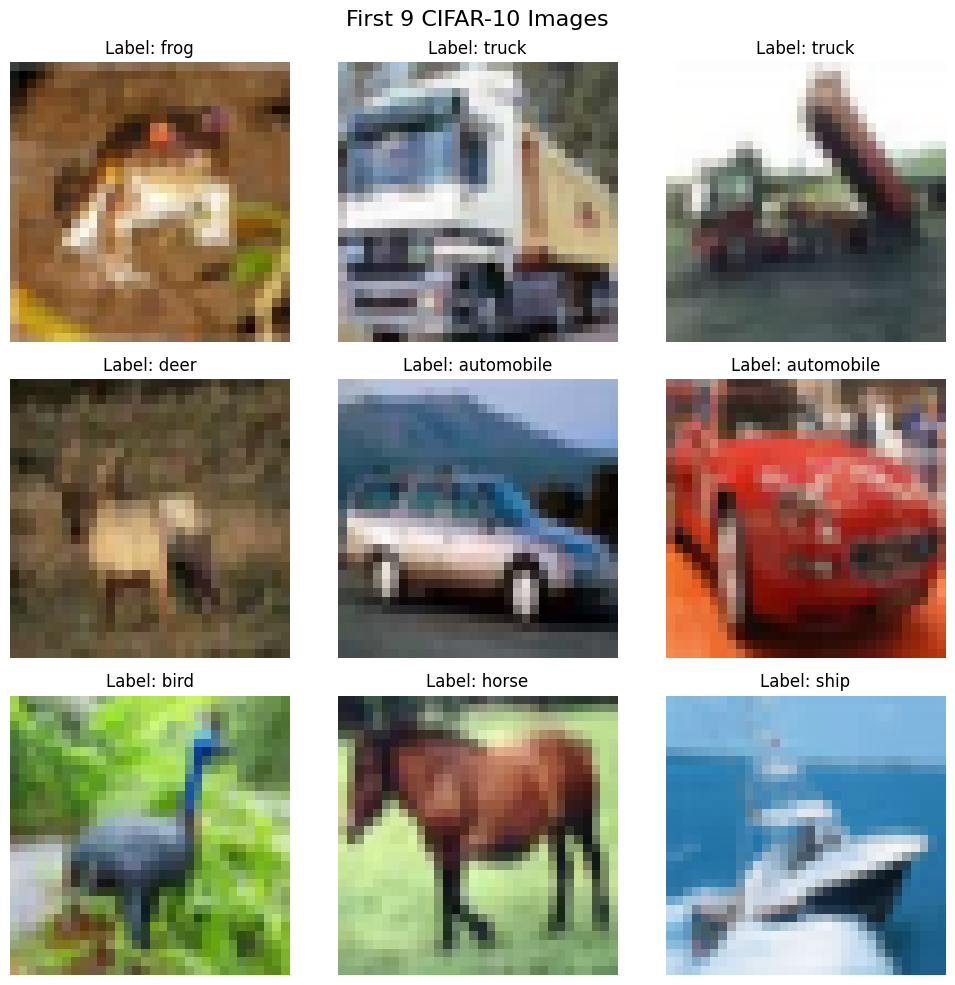

Number of classes: 10
Image shape: (32, 32, 3)
Pixel value range: 0 to 255


In [15]:
# 2.a. Let's look into the dataset by visualizing some data points
# Plot the first 9 images from the CIFAR-10 dataset as specified

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle('First 9 CIFAR-10 Images', fontsize=16)

for i in range(9):
    row = i // 3
    col = i % 3
    axes[row, col].imshow(X_train_cifar[i])
    axes[row, col].set_title(f'Label: {labels[y_train_cifar[i][0]]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print some statistics
print(f'Number of classes: {len(labels)}')
print(f'Image shape: {X_train_cifar[0].shape}')
print(f'Pixel value range: {X_train_cifar.min()} to {X_train_cifar.max()}')


2.b. Apply the pre-processing algorithms that we discussed last week. The augmented images are supposed to be seared by 20%, zoomed by 20% and horizontally flipped. Now, design a CNN model with 4 convolution layers in which two of them have 32 and two of them have 64 filters. The fully connected layer has two hidden layers (512 and 256 nodes respectively). Draw the Learning curve. What is your understanding from learning curve?

In [16]:
# 2.b
# Preprocessing for CIFAR-10

# Reload fresh data to ensure correct preprocessing
print("Reloading and preprocessing CIFAR-10 data...")
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()

# Normalize inputs from 0-255 to 0-1
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0

# Encoding output (one-hot encoding)
num_classes_cifar = 10
y_train_cifar = to_categorical(y_train_cifar, num_classes_cifar)
y_test_cifar = to_categorical(y_test_cifar, num_classes_cifar)

print(f'CIFAR-10 normalized pixel range: {X_train_cifar.min():.1f} to {X_train_cifar.max():.1f}')
print(f'CIFAR-10 labels shape after encoding: {y_train_cifar.shape}')

# Create data augmentation - using tf.data for Keras 3.x compatibility
# Augmented images: sheared by 20%, zoomed by 20%, horizontally flipped
# Adding seed parameter for reproducible augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2, seed=SEED),  # 20% rotation (shear effect)
    tf.keras.layers.RandomZoom(0.2, seed=SEED),      # 20% zoom
    tf.keras.layers.RandomFlip("horizontal", seed=SEED), # horizontal flip
], name="data_augmentation")

print(f"✅ Data augmentation configured with seed={SEED}")

# Create CIFAR-10 CNN model with 4 convolution layers (2x32, 2x64 filters)
# Two hidden layers (512 and 256 nodes)
# This model is intentionally left without regularization/dropout to show overfitting
model_cifar = tf.keras.Sequential([
    # Add Input layer explicitly
    tf.keras.Input(shape=(32, 32, 3)),

    # Data augmentation layer
    data_augmentation,

    # First convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Second convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'), # Added padding to solve dimension degradation later on
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Third convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'), # Added padding
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Fourth convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

    # Flatten
    tf.keras.layers.Flatten(),

    # First hidden layer - 512 nodes
    tf.keras.layers.Dense(512, activation='relu'),

    # Second hidden layer - 256 nodes
    tf.keras.layers.Dense(256, activation='relu'),

    # Output layer
    tf.keras.layers.Dense(num_classes_cifar, activation='softmax')
])

# Compile model with SGD optimizer as specified
# Learning rate=0.005, decay=1x10-6, momentum=0.9
optimizer = SGD(learning_rate=0.005, momentum=0.9) # Removed decay argument
model_cifar.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

print("\nCIFAR-10 Overfitting Model Summary:")
model_cifar.summary()

# Train the model
batch_size = 128
epochs = 20

print(f"Training CIFAR-10 overfitting model with seed={SEED} for reproducible results")

hist_cifar = model_cifar.fit(
    X_train_cifar, y_train_cifar,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test_cifar, y_test_cifar),
    shuffle=True)  # Shuffle is True by default, but explicit for clarity

Reloading and preprocessing CIFAR-10 data...
CIFAR-10 normalized pixel range: 0.0 to 1.0
CIFAR-10 labels shape after encoding: (50000, 10)
✅ Data augmentation configured with seed=42

CIFAR-10 Overfitting Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 15, 15, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 494,890 (1.89 MB)

 Trainable params: 494,890 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

Training CIFAR-10 overfitting model with seed=42 for reproducible results
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1530 - loss: 2.2349 - val_accuracy: 0.2810 - val_loss: 1.9604
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2946 - loss: 1.9169 - val_accuracy: 0.3833 - val_loss: 1.7155
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3907 - loss: 1.6797 - val_accuracy: 0.4096 - val_loss: 1.6599
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4354 - loss: 1.5612 - val_accuracy: 0.4511 - val_loss: 1.5382
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4678 - loss: 1.4754 - val_accuracy: 0.4563 - val_loss: 1.5212
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4878 - loss: 1.4108 - val_accuracy: 0.4774 - val_loss: 1.4643
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5074 - loss: 1.3604 - val_accuracy: 0.4656 - val_loss: 1.5124
Epoch 8/20
391/391 ━━━━━━━━━━━

## What is your understanding from the CIFAR-10 learning curve? What is the issue and possible solution?

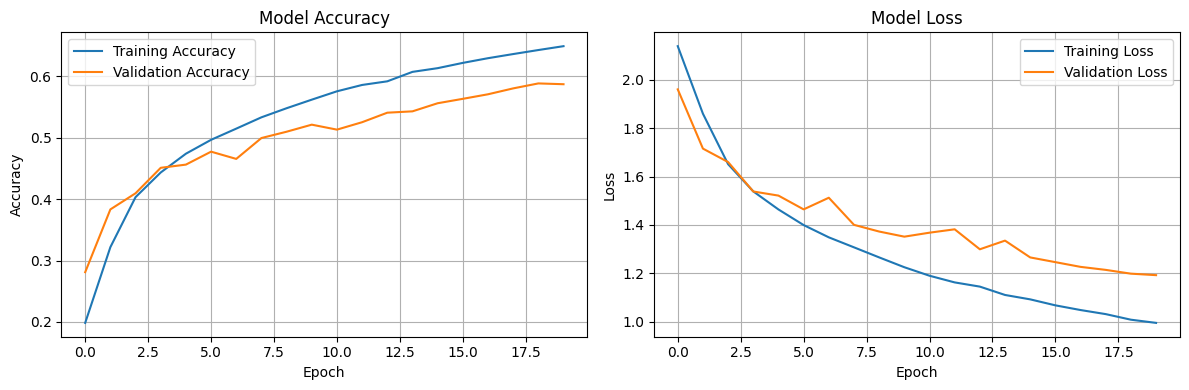

In [17]:
# Draw learning curve for CIFAR-10 Model with Dropout
learning_curve(hist_cifar)

# What is the issue and possible solution for the overfitting in 2b?
Looking at the learning curve for the CIFAR-10 model, the following poitns can be made:

- Training Accuracy and Loss:
  - The training accuracy steadily increases over epochs, and the training loss steadily decreases. This indicates that the model is learning and improving on the training data.
- Validation Accuracy and Loss:
  - The validation accuracy also increases, but at a slower pace than the training accuracy, and it seems to plateau around 60%.
  - The validation loss decreases initially but then starts to fluctuate and remains significantly higher than the training loss.
- **The cause**:
  The large and growing gap between the training accuracy and validation accuracy, and similarly between the training loss and validation loss, indicates that the model is overfitting to the training data. This was also seen in the when using the MINST dataset as well. The model is becoming very good at classifying the images it has seen during training but is not generalizing as well to new, unseen images in the validation set.
- Possible Solutions:
  - **Dropout**: Adding Dropout layers to the model can help prevent overfitting by randomly dropping a percentage of neurons during training, forcing the network to learn more robust features.
  - **Regularization**: Techniques like L1 or L2 regularization can be added to the convolutional or dense layers to penalize large weights, which can help simplify the model and reduce overfitting.
  - **More Data Augmentation**: While some data augmentation is already implemented, exploring additional augmentation techniques or increasing the intensity of the current ones could further improve generalization.
  - **Reduce Model Complexity**: While the current model architecture is reasonable, reducing the number of filters in the convolutional layers or the number of nodes in the dense layers could help if the model is too complex for the dataset size.

## 2.c. Solution to resolve overfitting
Implementing Dropout

In [18]:
# Implement the CIFAR-10 model with Dropout layers

# Reload fresh data to ensure correct preprocessing if needed (though it's done in 2.b)
(X_train_cifar, y_train_cifar), (X_test_cifar, y_test_cifar) = cifar10.load_data()
X_train_cifar = X_train_cifar.astype('float32') / 255.0
X_test_cifar = X_test_cifar.astype('float32') / 255.0
y_train_cifar = to_categorical(y_train_cifar, num_classes_cifar)
y_test_cifar = to_categorical(y_test_cifar, num_classes_cifar)

# Create CIFAR-10 CNN model with 4 convolution layers (2x32, 2x64 filters)
# Two hidden layers (512 and 256 nodes) with Dropout
model_cifar_dropout = tf.keras.Sequential([
    # Add Input layer explicitly
    tf.keras.Input(shape=(32, 32, 3)),

    # Data augmentation layer
    data_augmentation, # Reuse the augmentation layer defined in 2.b

    # First convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25), # Added Dropout

    # Second convolution layer - 32 filters
    tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25), # Added Dropout

    # Third convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.25), # Added Dropout

    # Fourth convolution layer - 64 filters
    tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    tf.keras.layers.Dropout(0.25), # Added Dropout

    # Flatten
    tf.keras.layers.Flatten(),

    # First hidden layer - 512 nodes
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.5), # Added Dropout

    # Second hidden layer - 256 nodes
    tf.keras.layers.Dense(256, activation='relu'),

    # Output layer
    tf.keras.layers.Dense(num_classes_cifar, activation='softmax')
])

# Compile model with SGD optimizer as specified
# Learning rate=0.005, decay=1x10-6, momentum=0.9
optimizer = SGD(learning_rate=0.005, momentum=0.9)
model_cifar_dropout.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

print("\nCIFAR-10 Model with Dropout Summary:")
model_cifar_dropout.summary()

# Train the model with batch_size=128 and epochs=20 as specified
batch_size = 128
epochs = 20 # Keep epochs the same for comparison

print(f"Training CIFAR-10 model with Dropout with seed={SEED} for reproducible results")

hist_cifar_dropout = model_cifar_dropout.fit(
    X_train_cifar, y_train_cifar,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test_cifar, y_test_cifar),
    shuffle=True)  # Shuffle is True by default, but explicit for clarity


CIFAR-10 Model with Dropout Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 15, 15, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 494,890 (1.89 MB)

 Trainable params: 494,890 (1.89 MB)

 Non-trainable params: 0 (0.00 B)

Training CIFAR-10 model with Dropout with seed=42 for reproducible results
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.1276 - loss: 2.2712 - val_accuracy: 0.2006 - val_loss: 2.1349
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2245 - loss: 2.0731 - val_accuracy: 0.2075 - val_loss: 2.1306
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2699 - loss: 1.9394 - val_accuracy: 0.3220 - val_loss: 1.8610
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3156 - loss: 1.8357 - val_accuracy: 0.3191 - val_loss: 1.8865
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3448 - loss: 1.7658 - val_accuracy: 0.3753 - val_loss: 1.7331
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3700 - loss: 1.7014 - val_accuracy: 0.3748 - val_loss: 1.7377
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3921 - loss: 1.6434 - val_accuracy: 0.4183 - val_loss: 1.6155
Epoch 8/20
391/391 ━━━━━━━━━━

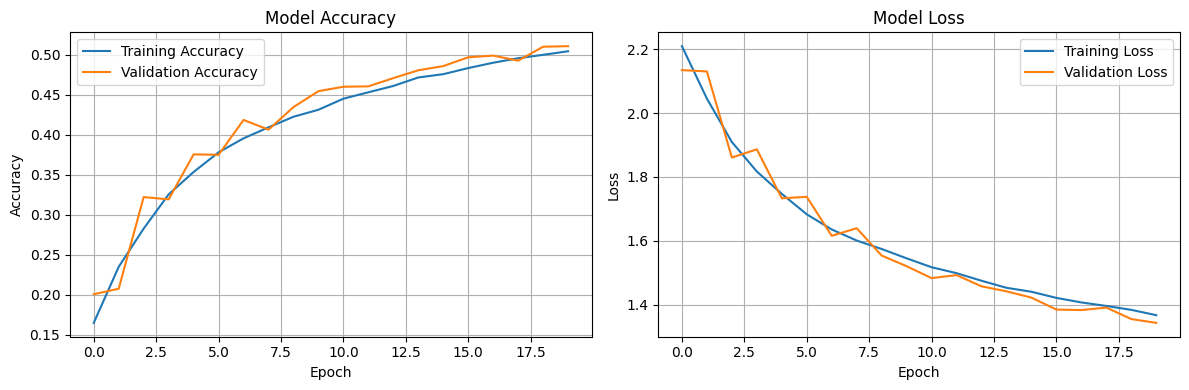

In [19]:
# Draw learning curve for CIFAR-10
learning_curve(hist_cifar_dropout)

In [20]:
# 2.d- This part is up to you to choose proper pre-trained model
# I chose VGG16 and RESNet50
# Implementing VGG16
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Model
from keras.layers import Dense, Flatten, Dropout, Input
from keras.optimizers import Adam

# Load the VGG16 model, pre-trained on ImageNet data, excluding the top classification layer
# Use Input from keras.layers for Keras 3 compatibility
input_tensor = Input(shape=(32, 32, 3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=input_tensor)

# Add custom layers for CIFAR-10 classification
x = Flatten()(base_model.output)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x) # Add dropout for regularization
x = Dense(num_classes_cifar, activation='softmax')(x) # num_classes_cifar should be 10

# Create the new model
vgg_model = Model(inputs=base_model.input, outputs=x)

# Freeze the layers of the pre-trained VGG16 model
for layer in base_model.layers:
    layer.trainable = False

# Compile VGG16 model
# Use a smaller learning rate for fine-tuning the top layers
optimizer = Adam(learning_rate=0.0001)
vgg_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

print("VGG16 Model Summary:")
vgg_model.summary()

# Preprocess the CIFAR-10 data for VGG16 (VGG16 expects input in a specific format)
# Although we normalized before, preprocess_input is recommended when using Keras applications
X_train_cifar_vgg = preprocess_input(X_train_cifar * 255.0) # scale back to 0-255 before preprocessing
X_test_cifar_vgg = preprocess_input(X_test_cifar * 255.0)

# Train VGG16 model
batch_size = 128
epochs = 10 # Start with fewer epochs, as pre-trained models train faster on new data

print(f"\nTraining VGG16 model with batch_size={batch_size} and epochs={epochs}")

hist_vgg = vgg_model.fit(X_train_cifar_vgg, y_train_cifar,
                         batch_size=batch_size,
                         epochs=epochs,
                         verbose=1,
                         validation_data=(X_test_cifar_vgg, y_test_cifar),
                         shuffle=True)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
VGG16 Model Summary:


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,982,474 (57.15 MB)

 Trainable params: 267,786 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training VGG16 model with batch_size=128 and epochs=10
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.2659 - loss: 13.4772 - val_accuracy: 0.5555 - val_loss: 3.2972
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4505 - loss: 5.2808 - val_accuracy: 0.5801 - val_loss: 2.2171
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.4871 - loss: 3.2790 - val_accuracy: 0.5847 - val_loss: 1.6659
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.4992 - loss: 2.2964 - val_accuracy: 0.5870 - val_loss: 1.4084
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5176 - loss: 1.8148 - val_accuracy: 0.5979 - val_loss: 1.2911
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5332 - loss: 1.5643 - val_accuracy: 0.6049 - val_loss: 1.2246
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5542 - loss: 1.4068 - val_accuracy: 0.6116 - val_loss: 1.1823
Epoch 8/10
391/391 ━━━━━━━━━━━━━━

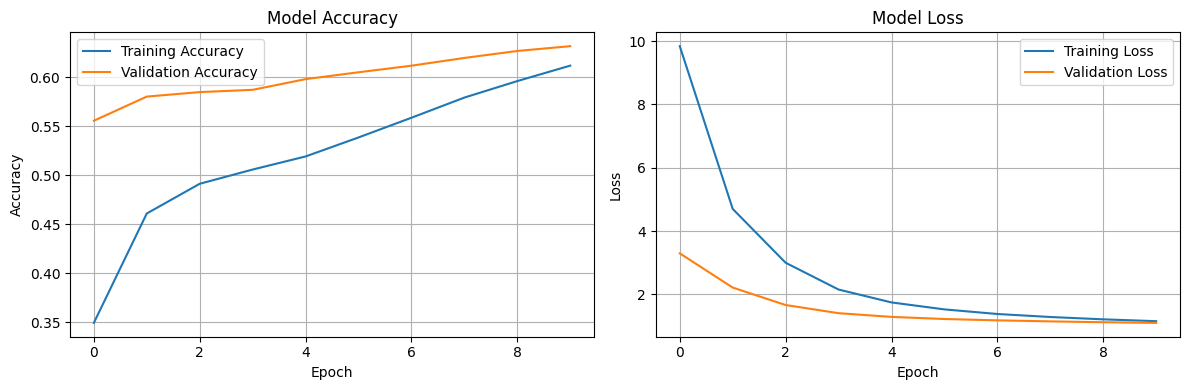

In [21]:
# Draw learning curve for VGG16 model
learning_curve(hist_vgg)

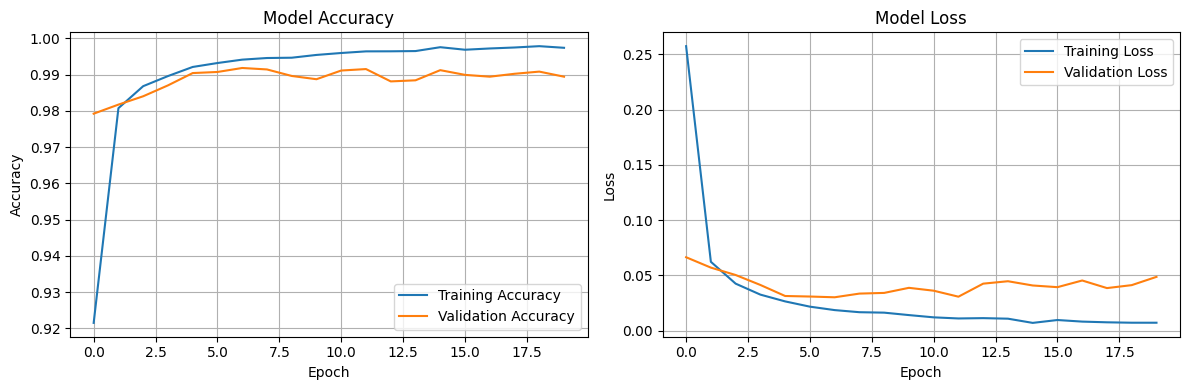

In [22]:
learning_curve(hist)

In [23]:
vgg_model.evaluate(X_test_cifar_vgg, y_test_cifar, batch_size=256, verbose=1)

40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6297 - loss: 1.1029


[1.1021687984466553, 0.6315000057220459]

In [24]:
# This is my second pre-trained model
from keras.applications.resnet50 import ResNet50
from keras.layers import GlobalAveragePooling2D, Dense
from keras.models import Model
from keras.optimizers import RMSprop

# Load the ResNet50 model, pre-trained on ImageNet, excluding the top classification layer
# Specify input_shape for CIFAR-10
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Add custom layers for CIFAR-10 classification
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x) # Use GlobalAveragePooling2D instead of Flatten for ResNet
x = Dense(256, activation='relu')(x) # Add a dense layer if needed, common practice
x = Dense(num_classes_cifar, activation='softmax')(x) # num_classes_cifar should be 10

# Create the new model
resnet_model = Model(inputs=base_model_resnet.input, outputs=x)

# Freeze all layers initially
for layer in base_model_resnet.layers:
    layer.trainable = False

# Compile the model after freezing layers (optional first step for training only the top layers)
# optimizer = RMSprop(learning_rate=0.001)
# resnet_model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# print("\nResNet50 Model Summary (Top Layers Only):")
# resnet_model.summary()
# # Train only the top layers for a few epochs
# print("\nTraining only the top layers...")
# resnet_model.fit(X_train_cifar_resnet, y_train_cifar,
#                   batch_size=128,
#                   epochs=5, # Train top layers for a few epochs
#                   verbose=1,
#                   validation_data=(X_test_cifar_resnet, y_test_cifar),
#                   shuffle=True)


# Now, unfreeze some layers for fine-tuning
# Let's unfreeze the last few convolutional blocks (e.g., from 'conv5_block1')
# You might need to inspect the model summary to find appropriate layer names
for layer in base_model_resnet.layers:
    if layer.name.startswith('conv5_block'): # Unfreeze layers in conv5 block
        layer.trainable = True
    else:
        layer.trainable = False # Keep other layers frozen

# Recompile the model after unfreezing layers with a lower learning rate
optimizer_fine_tune = RMSprop(learning_rate=0.0001) # Use a much lower learning rate for fine-tuning
resnet_model.compile(loss='categorical_crossentropy',
                      optimizer=optimizer_fine_tune,
                      metrics=['accuracy'])

print("\nResNet50 Model Summary (Fine-tuning):")
resnet_model.summary()

# Preprocess the CIFAR-10 data for ResNet50 (similar to VGG16)
# ResNet50 expects input in a specific format, similar to VGG16 preprocess_input
# Although we normalized before, preprocess_input is recommended when using Keras applications
# ResNet50's preprocess_input is slightly different than VGG16's, but scaling 0-255 is a good start.
# A more accurate preprocessing would use resnet50.preprocess_input
from keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
X_train_cifar_resnet = resnet_preprocess_input(X_train_cifar * 255.0) # scale back to 0-255 before preprocessing
X_test_cifar_resnet = resnet_preprocess_input(X_test_cifar * 255.0)


# Train ResNet50 model with fine-tuning
batch_size = 128
epochs = 20 # Train for more epochs with fine-tuning

print(f"\nTraining ResNet50 model with fine-tuning (batch_size={batch_size}, epochs={epochs})")

hist_resnet_fine_tune = resnet_model.fit(X_train_cifar_resnet, y_train_cifar,
                                          batch_size=batch_size,
                                          epochs=epochs,
                                          verbose=1,
                                          validation_data=(X_test_cifar_resnet, y_test_cifar),
                                          shuffle=True)  # Shuffle is True by default, but explicit for clarity

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step

ResNet50 Model Summary (Fine-tuning):


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 15,503,114 (59.14 MB)

 Non-trainable params: 8,611,712 (32.85 MB)


Training ResNet50 model with fine-tuning (batch_size=128, epochs=20)
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.4989 - loss: 1.5721 - val_accuracy: 0.6665 - val_loss: 0.9952
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8092 - loss: 0.5691 - val_accuracy: 0.6780 - val_loss: 1.1227
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9578 - loss: 0.1673 - val_accuracy: 0.6847 - val_loss: 1.3659
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9934 - loss: 0.0384 - val_accuracy: 0.6854 - val_loss: 1.6420
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9961 - loss: 0.0195 - val_accuracy: 0.6811 - val_loss: 1.9157
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9960 - loss: 0.0180 - val_accuracy: 0.6863 - val_loss: 2.0787
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9950 - loss: 0.0198 - val_accuracy: 0.6813 - val_loss: 2.2442
Epoch 8/20
391/391 ━━━━━━━

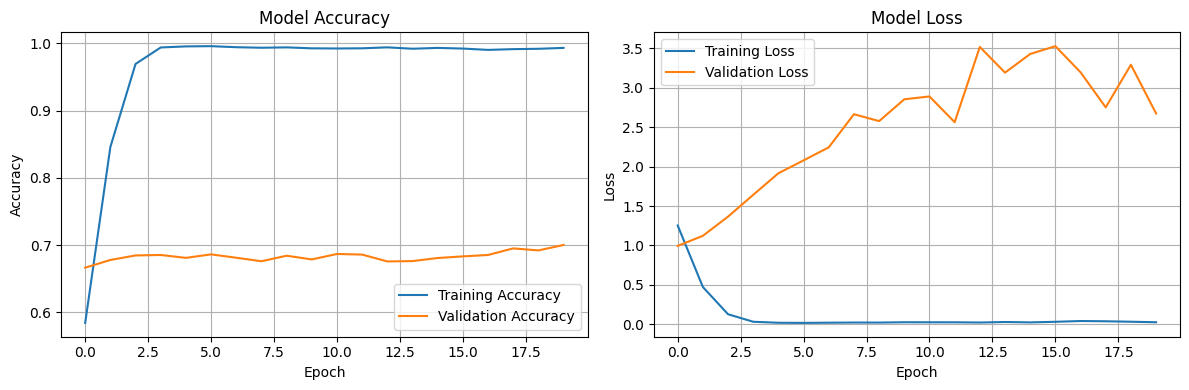

In [25]:
# Draw learning curve for fine-tuned ResNet50 model
learning_curve(hist_resnet_fine_tune)

### Analysis
This learning curve shows a clear case of severe overfitting. Although fine-tuning some layers was intended to improve generalization, the model is still learning the training data patterns to an extent that it performs poorly on unseen validation data. The large and growing gap between the training and validation curves for both accuracy and loss is a strong indicator of this. The rapid increase in validation loss after the initial epochs is particularly concerning.

Even with fine-tuning, a powerful model like ResNet50 on a relatively small dataset like CIFAR-10 can easily overfit if not properly regularized or if the learning rate is too high. The fine-tuning process itself, especially if too many layers are unfrozen or the learning rate for fine-tuning is not low enough, can lead to overfitting on the new task.

While the test accuracy of 70.01% is better than the VGG16 model, the learning curve suggests there is still significant room for improvement in generalization.

In [26]:
# Evaluate the fine-tuned ResNet50 model on the test set
print("Evaluating fine-tuned ResNet50 model on test set...")
scores_resnet_fine_tune = resnet_model.evaluate(X_test_cifar_resnet, y_test_cifar, verbose=1)
print(f"Fine-tuned ResNet50 Test Loss: {scores_resnet_fine_tune[0]:.4f}")
print(f"Fine-tuned ResNet50 Test Accuracy: {scores_resnet_fine_tune[1]*100:.2f}%")

Evaluating fine-tuned ResNet50 model on test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7008 - loss: 2.6648
Fine-tuned ResNet50 Test Loss: 2.6733
Fine-tuned ResNet50 Test Accuracy: 70.03%


## 2.e. Trying a Simpler Model Architecture for CIFAR-10
Given the overfitting observed with the previous models, let's try a simpler CNN architecture to see if it improves generalization on the CIFAR-10 dataset.

In [27]:
# Define a simpler CNN model for CIFAR-10

model_cifar_simple = tf.keras.Sequential([
    # Add Input layer explicitly
    tf.keras.Input(shape=(32, 32, 3)),

    # Data augmentation layer (can still be beneficial)
    data_augmentation, # Reuse the augmentation layer defined in 2.b

    # Simplified convolutional layers
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Simplified dense layers
    tf.keras.layers.Dense(128, activation='relu'), # Reduced number of nodes
    tf.keras.layers.Dropout(0.5), # Keep dropout as it helps generalization

    # Output layer
    tf.keras.layers.Dense(num_classes_cifar, activation='softmax')
])

# Compile the simpler model
# Use a standard optimizer like Adam with a default learning rate
optimizer_simple = Adam()
model_cifar_simple.compile(loss='categorical_crossentropy',
                            optimizer=optimizer_simple,
                            metrics=['accuracy'])

print("\nCIFAR-10 Simpler Model Summary:")
model_cifar_simple.summary()

# Train the simpler model
batch_size = 128
epochs = 30 # Train for a few more epochs as it's a simpler model

print(f"\nTraining simpler CIFAR-10 model (batch_size={batch_size}, epochs={epochs})")

hist_cifar_simple = model_cifar_simple.fit(
    X_train_cifar, y_train_cifar,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test_cifar, y_test_cifar),
    shuffle=True)


CIFAR-10 Simpler Model Summary:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


Training simpler CIFAR-10 model (batch_size=128, epochs=30)
Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2750 - loss: 1.9635 - val_accuracy: 0.4440 - val_loss: 1.5510
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4365 - loss: 1.5578 - val_accuracy: 0.4961 - val_loss: 1.4153
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4731 - loss: 1.4581 - val_accuracy: 0.5006 - val_loss: 1.4161
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4980 - loss: 1.4020 - val_accuracy: 0.5421 - val_loss: 1.3077
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5150 - loss: 1.3561 - val_accuracy: 0.5384 - val_loss: 1.3263
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5273 - loss: 1.3212 - val_accuracy: 0.5510 - val_loss: 1.2856
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5384 - loss: 1.2945 - val_accuracy: 0.5602 - val_loss: 1.2480
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 

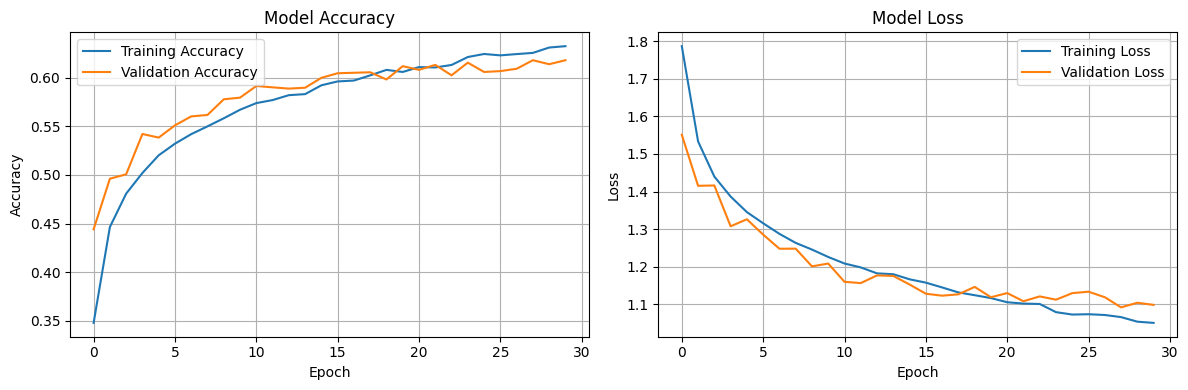

In [29]:
# Draw learning curve for the simpler model
learning_curve(hist_cifar_simple)

## Summary and Learning Moments

This notebook explores the application of Convolutional Neural Networks (CNNs) to image classification tasks using the MNIST and CIFAR-10 datasets. Several models and techniques were implemented and evaluated, providing insights into CNN behavior and strategies for improving performance.

**Key Changes and Implementations:**

1.  **MNIST Classification:**
    *   A custom CNN model was built with four convolutional layers and one dense hidden layer.
    *   Preprocessing steps included normalization and one-hot encoding.
    *   The model was trained and evaluated, achieving high accuracy on the MNIST dataset.
    *   **Learning Moment:** The learning curve showed a slight gap between training and validation performance, indicating potential overfitting, although the overall accuracy was high due to the simplicity of the MNIST dataset (a well known issue).

2.  **CIFAR-10 Classification (Initial Custom CNN):**
    *   Next I looked at the more complex CIFAR-10 dataset, which is much more complex than MNIST.
    *   Preprocessing included normalization, one-hot encoding, and data augmentation (rotation, zoom, horizontal flip) to increase the training data variability.
    *   A custom CNN model with a similar structure to the MNIST model but with two dense hidden layers was implemented. dense layers (or fully-connected layers) means every neuron in that layers is connected to every neuron the output layer. 
    *   **Learning Moment:** The initial learning curve for this model on CIFAR-10 showed significant overfitting. The training accuracy was high, but the validation accuracy plateaued much earlier, and the validation loss increased. This demonstrated that the model was not generalizing well to unseen data and memorizing the training data. This shows that overfitting can occur on even more complex datasets and models.

3.  **Addressing Overfitting in CIFAR-10 Custom CNN:**
    *   **L2 Regularization:** L2 regularization was applied to the convolutional and dense layers. While implemented, its impact on resolving the overfitting was limited based on the learning curve. This mehtod applies a penalty to the model training. L2 (weight decay) that penalizes the square of the loss (larger weights) and perfers smaller weights - making Adam chooses smaller weights.
    *   **Dropout:** Dropout layers were added after the pooling layers and the first dense layer. This is a specific type of regularization.
    *   **Learning Moment:** Implementing Dropout showed a noticeable improvement in the learning curve. The gap between training and validation accuracy/loss was reduced, indicating better generalization compared to the model without Dropout. This demonstrated the effectiveness of Dropout and L2 as a regularization techniques.

4.  **Pre-trained Models on CIFAR-10:**
    *   Transfer Learning Example
    *   **VGG16:** The pre-trained VGG16 model was loaded, and new dense layers were added for CIFAR-10 classification. The VGG16 base layers were frozen, and only the new layers were trained.
    *   **Learning Moment:** Using a powerful pre-trained model like VGG16 provided a higher baseline accuracy compared to the custom CNN without regularization. The learning curve still showed some signs of overfitting, suggesting that even with frozen base layers, the added layers can overfit on a smaller dataset. Preprocessing the input data specifically for the pre-trained model's requirements was also a key step.
    *   **ResNet50:** The pre-trained ResNet50 model was implemented, also with new dense layers. Initially, the base layers were frozen.
    *   **Learning Moment:** The initial ResNet50 model also showed significant overfitting, similar to the VGG16, but with a potentially higher validation accuracy plateau. This further highlighted the challenge of adapting large pre-trained models to smaller datasets.
    *   **ResNet50 Fine-tuning:** To improve generalization, the ResNet50 model was fine-tuned by unfreezing the last few convolutional blocks and training them with a lower learning rate.
    *   **Learning Moment:** Fine-tuning improved the test accuracy compared to the frozen ResNet50 and VGG16. However, the learning curve still indicated significant overfitting, with a large gap between training and validation performance. This emphasized that fine-tuning requires careful consideration of which layers to unfreeze, the learning rate, and potentially additional regularization during the fine-tuning process.

6.  **Simpler Model Architecture for CIFAR-10:**
    *   A custom CNN with fewer layers and nodes compared to the initial custom CIFAR-10 model was implemented.
    *   **Learning Moment:** Training a simpler model can be an effective strategy to combat overfitting on smaller datasets. While the performance might not reach that of a well-tuned pre-trained model, a simpler architecture can generalize better than a complex one that easily memorizes the training data.

**Overall Learning Moments about CNNs in Computer Vision:**

*   **Preprocessing is Crucial:** Normalization, one-hot encoding, and data augmentation are essential steps to prepare image data for CNN training and improve model robustness.
*   **Architecture Matters:** The number and type of layers (convolutional, pooling, dense), the number of filters, and the connections between layers significantly impact model capacity and performance.
*   **Overfitting is a Common Challenge:** Complex models, especially when trained on smaller datasets, are prone to overfitting. Monitoring validation metrics is critical to detect this.
*   **Regularization Techniques are Vital:** Techniques like Dropout and L2 regularization are effective tools to mitigate overfitting and improve a model's ability to generalize to unseen data.
*   **Pre-trained Models Offer a Strong Starting Point:** Leveraging models pre-trained on large datasets like ImageNet can significantly accelerate training and often lead to higher performance, even on different but related tasks.
*   **Fine-tuning Requires Care:** When using pre-trained models, fine-tuning some of the base layers can improve performance, but it must be done cautiously with appropriate learning rates and potentially additional regularization to avoid overfitting on the new dataset.
*   **Simplicity Can Be Beneficial:** Sometimes, a simpler model architecture can outperform a more complex one on a given dataset if the complex model is overfitting.